In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
column_names = ['train_data_size', 'val_data_size', 'random_seed', 'representation', 
                'train_accuracy', 'val_accuracy', 'test_accuracy', 'num_epochs', 'batch_size']

In [3]:
df = pd.read_csv('../results/dvs128_cnn_01_to_09_batch32_3seeds.txt', names=column_names, skiprows=1)

In [4]:
df.head()

,train_data_size,val_data_size,random_seed,representation,train_accuracy,val_accuracy,test_accuracy,num_epochs,batch_size
0,0.1,0.1,13,binary,0.538194,0.411290,0.518939,0,32
1,0.1,0.1,13,n_bins,0.569444,0.326613,0.401515,0,32
2,0.1,0.1,42,binary,0.655423,0.450000,0.636364,0,32
3,0.1,0.1,42,n_bins,0.714506,0.428371,0.518939,0,32
4,0.1,0.1,93,binary,0.610340,0.432584,0.553030,0,32


In [5]:
grouped_data = df.groupby(['train_data_size', 'representation']).agg({
    'train_accuracy': 'mean',
    'val_accuracy': 'mean',
    'test_accuracy': 'mean'
}).reset_index()

In [6]:
grouped_data.head()

,train_data_size,representation,train_accuracy,val_accuracy,test_accuracy
0,0.1,binary,0.601319,0.431292,0.569444
1,0.1,n_bins,0.629527,0.383008,0.470960
2,0.2,binary,0.598341,0.499573,0.635101
3,0.2,n_bins,0.671142,0.477925,0.569444
4,0.3,binary,0.759068,0.596222,0.650253


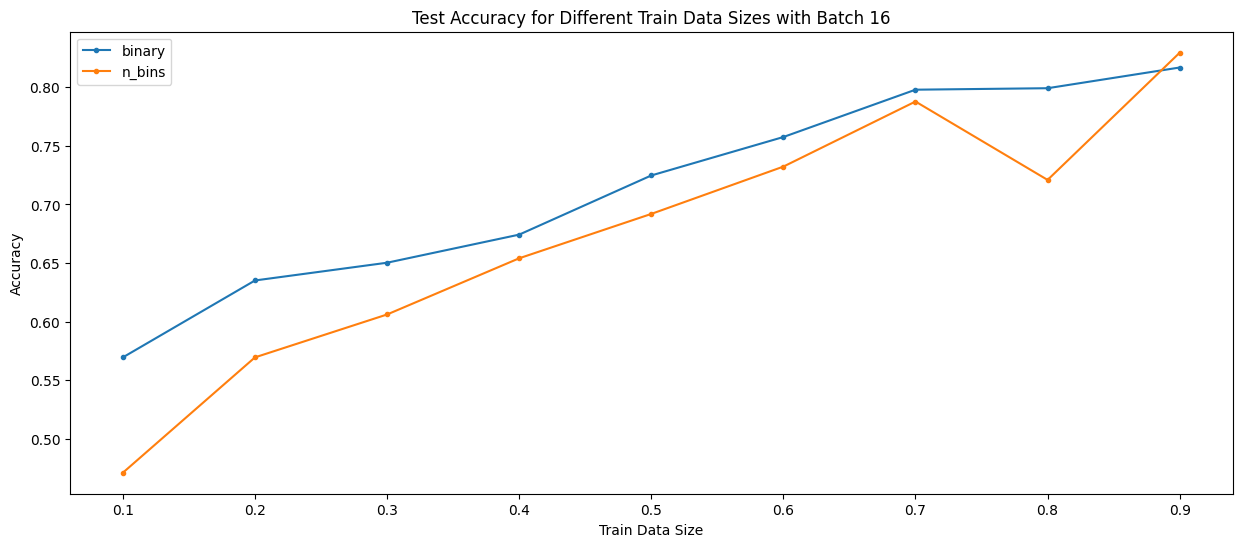

In [7]:
fig, ax = plt.subplots(figsize=(15, 6))

for representation in grouped_data['representation'].unique():
    rep_data = grouped_data[grouped_data['representation'] == representation]
    plt.plot(rep_data['train_data_size'], rep_data['test_accuracy'], label=f'{representation}', marker='.')

plt.xlabel('Train Data Size')
plt.ylabel('Accuracy')
plt.title('Test Accuracy for Different Train Data Sizes with Batch 16')
plt.legend()
plt.show()

In [8]:
df2 = pd.read_csv('../results/dvs128_cnn_09_batch32_10seeds.txt')

In [9]:
df2.head()

,train_data_size,val_data_size,random_seed,representation,train_acc,val_acc,test_acc,num_epochs,batch_size
0,0.9,0.1,13,binary,0.851031,0.726210,0.837121,0,32
1,0.9,0.1,42,binary,0.840378,0.747875,0.795455,0,32
2,0.9,0.1,44,binary,0.769691,0.689482,0.742424,0,32
3,0.9,0.1,45,binary,0.889249,0.777368,0.810606,0,32
4,0.9,0.1,59,binary,0.884610,0.783518,0.825758,0,32


In [10]:
df2['num_epochs'] = df2['num_epochs'] + 1

grouped_data2 = df2.groupby(['representation']).agg({
    'train_acc': ['mean', 'std'],
    'val_acc': ['mean', 'std'],
    'test_acc': ['mean', 'std'],
    'num_epochs': 'mean',
}).reset_index()

In [11]:
grouped_data2.head()

representation train_acc             val_acc            test_acc            \
                      mean       std      mean       std      mean       std   
0         binary  0.857188  0.042257  0.762276  0.048730  0.826178  0.044475   
1         n_bins  0.794517  0.105137  0.681982  0.096996  0.798822  0.066219   

  num_epochs  
        mean  
0        1.0  
1        1.0

C:\Users\osvat\AppData\Local\Temp\ipykernel_41700\530449193.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\osvat\AppData\Local\Temp\ipykernel_41700\530449193.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


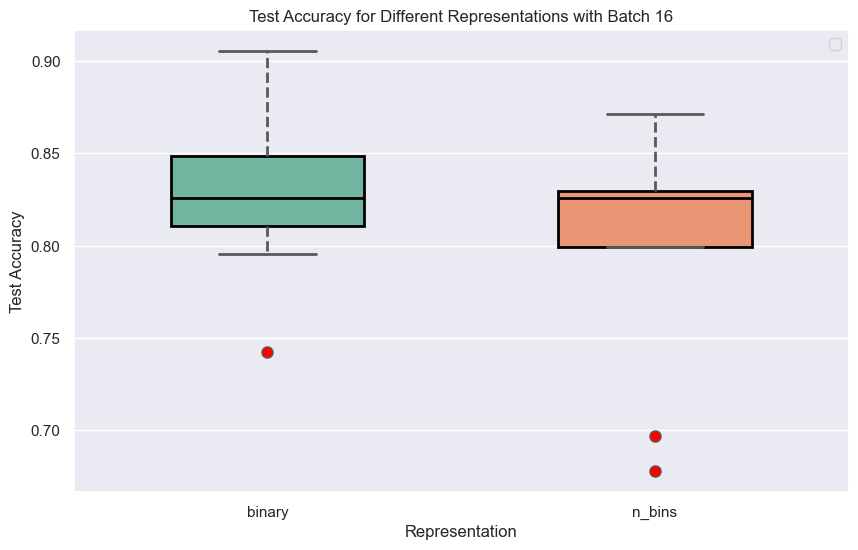

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.set_style()

sns.boxplot(
    data=df2, 
    x="representation", 
    y="test_acc",
    palette="Set2",  # Different colors for each box
    width=0.5,       # Adjust box width
    linewidth=2,     # Border thickness
    flierprops={
        "marker": "o",          # Use points for outliers
        "markerfacecolor": "red",  # Outlier color
        "markersize": 8,        # Outlier size
    },
    whiskerprops={"linestyle": "--"},  # Dashed whiskers
    boxprops={"edgecolor": "black"},  # Box border color
    medianprops={"color": "black"},   # Median line color
)

ax.set_xlabel('Representation')
ax.set_ylabel('Test Accuracy')
ax.set_title('Test Accuracy for Different Representations with Batch 16')
ax.legend()

In [13]:
grouped_data2 = grouped_data2.round(2)
grouped_data2.to_csv('./dvs128_cnn_09_batch32_10seeds_grouped.csv', index=False)